# IAF 604: Final Project #1
## Random Forest & XGBoost — Healthcare Classification
**Amber Locasto**

The goal of this project is to predict patient test results (`Normal`, `Abnormal`, or `Inconclusive`) using information like age, billing amount, admission details, and medical condition. I wanted to compare Random Forest and XGBoost to see which model handled this multiclass classification problem better.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
import sys 
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [3]:
df = pd.read_csv("project1_data.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (55500, 15)

Columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11 

The dataset contains 55,500 observations and 15 variables. A missing value check showed that there are no null values in the dataset, so no imputation was required before modeling.

# Target Distribution

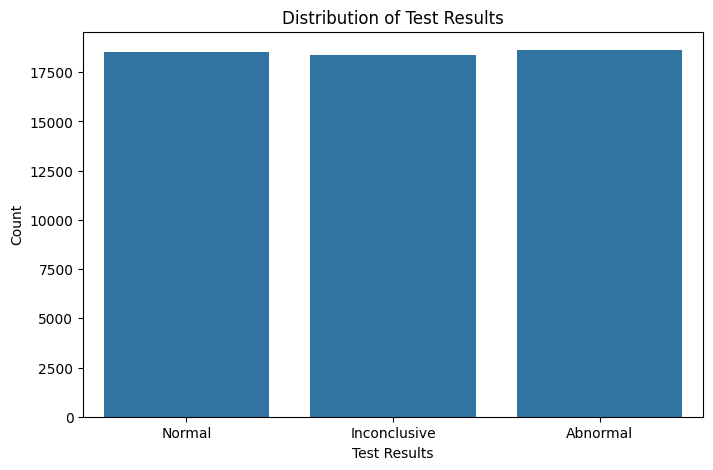

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64
Test Results
Abnormal        0.335622
Normal          0.333640
Inconclusive    0.330739
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Test Results")
plt.title("Distribution of Test Results")
plt.xlabel("Test Results")
plt.ylabel("Count")
plt.show()

print(df["Test Results"].value_counts())
print(df["Test Results"].value_counts(normalize=True))

The target variable is well balanced across the three classes, which is helpful because it reduces the risk of the model favoring one category too heavily. This also makes stratified train/test splitting appropriate.

# Summary Statistics for Numeric Features

In [7]:
df[["Age", "Billing Amount", "Room Number"]].describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


- Age mean: about 51.5
- Billing Amount mean: about 25,539
- Room Number mean: about 301
- Billing includes some negative values, which are unusual

I looked at summary statistics for the numeric columns to get a quick feel for the data. Age and room number looked pretty reasonable overall, while billing amount had a wide range and included some unusual values.

# Feature Engineering

In [8]:
#Converting dates and creating Length of Stay feature
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

df[["Date of Admission", "Discharge Date", "Length of Stay"]].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


**Length of Stay** = Discharge Date - Admission Date --> I created a new feature called `Length of Stay` by subtracting the admission date from the discharge date. I kept this feature because it is more directly useful than the raw dates and may capture differences in patient cases better than the original date columns alone.

In [9]:
#Summary statistics for Length of Stay
df[["Age", "Billing Amount", "Room Number", "Length of Stay"]].describe()

,Age,Billing Amount,Room Number,Length of Stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829,15.509009
std,19.602454,14211.454431,115.243069,8.659600
min,13.000000,-2008.492140,101.000000,1.000000
25%,35.000000,13241.224652,202.000000,8.000000
50%,52.000000,25538.069376,302.000000,15.000000
75%,68.000000,37820.508436,401.000000,23.000000
max,89.000000,52764.276736,500.000000,30.000000


# EDA Plots

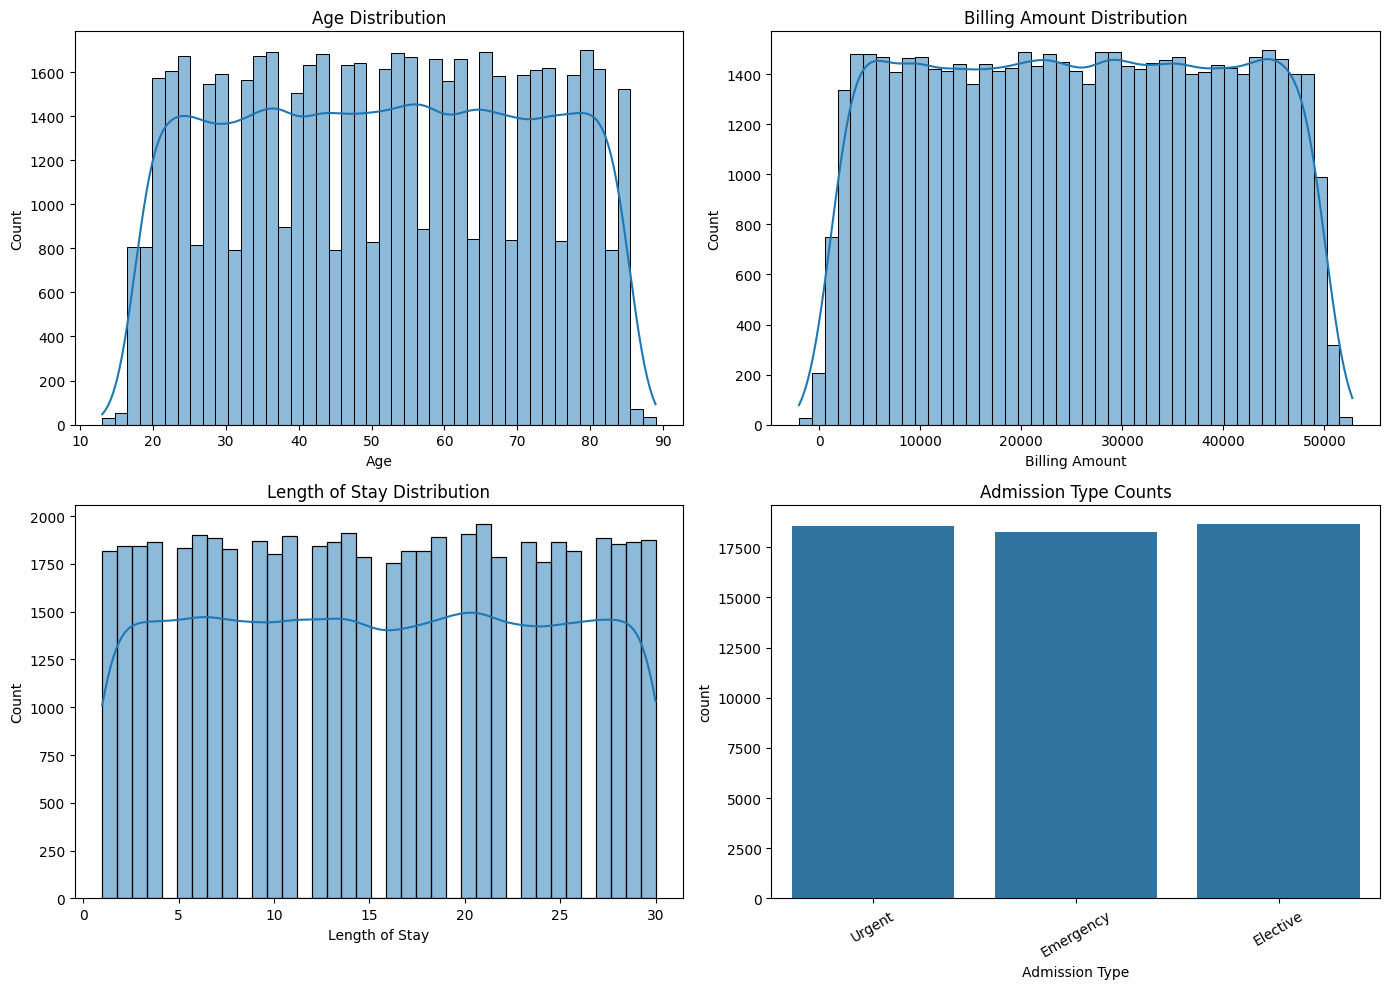

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df["Age"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.histplot(df["Billing Amount"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Billing Amount Distribution")

sns.histplot(df["Length of Stay"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Length of Stay Distribution")

sns.countplot(data=df, x="Admission Type", ax=axes[1,1])
axes[1,1].set_title("Admission Type Counts")
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

These plots gave me a better feel for how the main variables were distributed before I moved into preprocessing and model building.

# Preprocessing

In [11]:
target = "Test Results"

X = df.drop(columns=[target, "Name", "Doctor", "Hospital", "Date of Admission", "Discharge Date"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (55500, 10)
y shape: (55500,)

Feature columns:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Medication', 'Length of Stay']


I removed identifier-like columns and the original date fields because they are less useful in raw form. Instead, I kept the engineered Length of Stay feature, which is more directly meaningful for prediction.

In [12]:
#defining categorical and numerical features
categorical_cols = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Admission Type",
    "Medication",
    "Insurance Provider"
]

numerical_cols = [
    "Age",
    "Billing Amount",
    "Room Number",
    "Length of Stay"
]

In [13]:
#preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

Numerical variables were standardized using StandardScaler to keep the preprocessing consistent. Categorical variables were one-hot encoded so that Random Forest and XGBoost could use them as model inputs.

In [14]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape:", X_test_proc.shape)

X_train_proc shape: (38850, 33)
X_test_proc shape: (16650, 33)


I used a stratified 70/30 train-test split so that each of the three test result classes remained proportionally represented in both sets.

# Baseline Random Forest

In [15]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_proc, y_train)
rf_base_pred = rf_baseline.predict(X_test_proc)
rf_base_proba = rf_baseline.predict_proba(X_test_proc)

rf_base_accuracy = accuracy_score(y_test, rf_base_pred)
rf_base_precision = precision_score(y_test, rf_base_pred, average="macro")
rf_base_recall = recall_score(y_test, rf_base_pred, average="macro")
rf_base_f1 = f1_score(y_test, rf_base_pred, average="macro")
rf_base_auc = roc_auc_score(y_test, rf_base_proba, multi_class="ovr")

print("Baseline RF Accuracy:", rf_base_accuracy)
print("Baseline RF Precision:", rf_base_precision)
print("Baseline RF Recall:", rf_base_recall)
print("Baseline RF F1-Macro:", rf_base_f1)
print("Baseline RF ROC-AUC:", rf_base_auc)

Baseline RF Accuracy: 0.4231831831831832
Baseline RF Precision: 0.42318633740221984
Baseline RF Recall: 0.423130945658132
Baseline RF F1-Macro: 0.42309165417065614
Baseline RF ROC-AUC: 0.6238011336713594


The baseline Random Forest gave me a starting point for comparison. The performance was moderate, which suggests there is some signal in the data, but not a very strong one.

In [16]:
#classification report
print(classification_report(y_test, rf_base_pred))

              precision    recall  f1-score   support

    Abnormal       0.42      0.44      0.43      5588
Inconclusive       0.42      0.42      0.42      5507
      Normal       0.42      0.42      0.42      5555

    accuracy                           0.42     16650
   macro avg       0.42      0.42      0.42     16650
weighted avg       0.42      0.42      0.42     16650



The classification report showed fairly similar performance across the three classes, which matches the balanced target distribution. No single class strongly dominated the predictions.

# Training Time for Baseline Random Forest

In [17]:
start = time.time()

rf_baseline.fit(X_train_proc, y_train)

rf_base_time = time.time() - start

# Tuning the Random Forest

In [18]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_proc, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF params:", grid_rf.best_params_)

Best RF params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


Next, I tuned the Random Forest by testing a few combinations of tree count, depth, and minimum split size. I used stratified cross-validation so the class balance stayed consistent during tuning too.

# Evaluating the Tuned Random Forest 

In [19]:
rf_tuned_pred = best_rf.predict(X_test_proc)
rf_tuned_proba = best_rf.predict_proba(X_test_proc)

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred, average="macro")
rf_tuned_recall = recall_score(y_test, rf_tuned_pred, average="macro")
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred, average="macro")
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_proba, multi_class="ovr")

print("Tuned RF Accuracy:", rf_tuned_accuracy)
print("Tuned RF Precision:", rf_tuned_precision)
print("Tuned RF Recall:", rf_tuned_recall)
print("Tuned RF F1-Macro:", rf_tuned_f1)
print("Tuned RF ROC-AUC:", rf_tuned_auc)

Tuned RF Accuracy: 0.42348348348348347
Tuned RF Precision: 0.4236371155088508
Tuned RF Recall: 0.42343232678260545
Tuned RF F1-Macro: 0.4234375594299045
Tuned RF ROC-AUC: 0.6106322828477972


Hyperparameter tuning produced only modest gains. That tells me the model was already close to its best setup, or that the dataset itself does not have very strong predictive patterns.

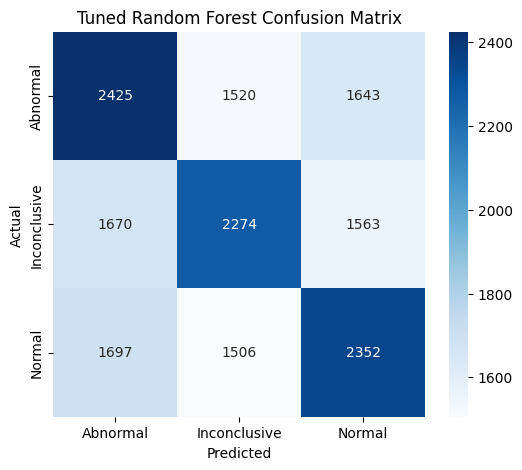

In [20]:
#confusion matrix
rf_cm = confusion_matrix(y_test, rf_tuned_pred)
rf_labels = best_rf.classes_

plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_labels, yticklabels=rf_labels)
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows where the model is mixing up classes. This is useful because accuracy alone does not show which specific categories are being confused.

# Random Forest Feature Importance 

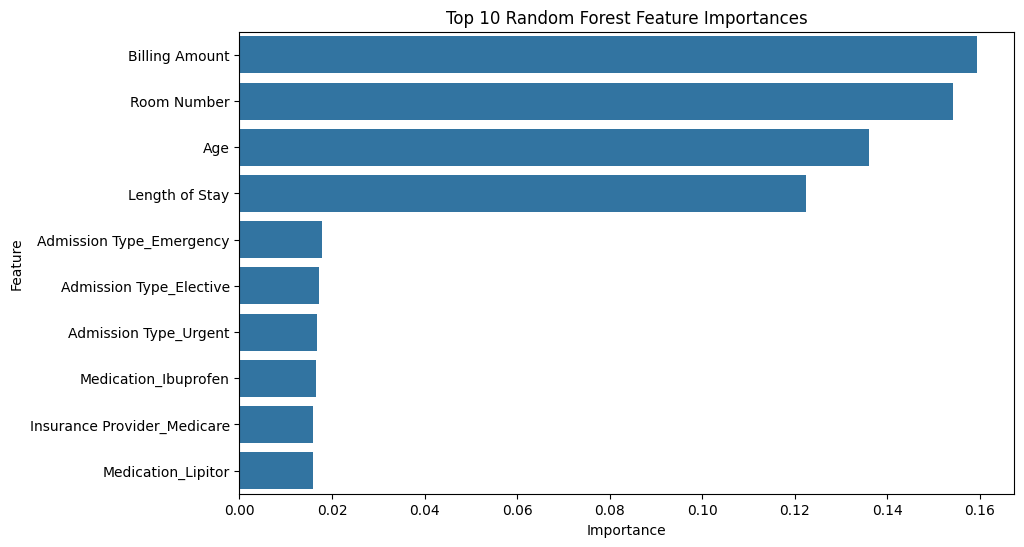

,Feature,Importance
1,Billing Amount,0.159458
2,Room Number,0.154250
0,Age,0.136089
3,Length of Stay,0.122336
21,Admission Type_Emergency,0.017858
20,Admission Type_Elective,0.017282
22,Admission Type_Urgent,0.016842
24,Medication_Ibuprofen,0.016446
31,Insurance Provider_Medicare,0.015974
25,Medication_Lipitor,0.015881


In [21]:
encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

rf_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_top10 = rf_importances.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=rf_top10, x="Importance", y="Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

rf_top10

Feature importance shows me which variables contributed most to the model’s decisions. In this project, variables such as billing amount, age, length of stay, and certain encoded medical categories appear to be the most influential predictors.

# ROC-AUC for Random Forest

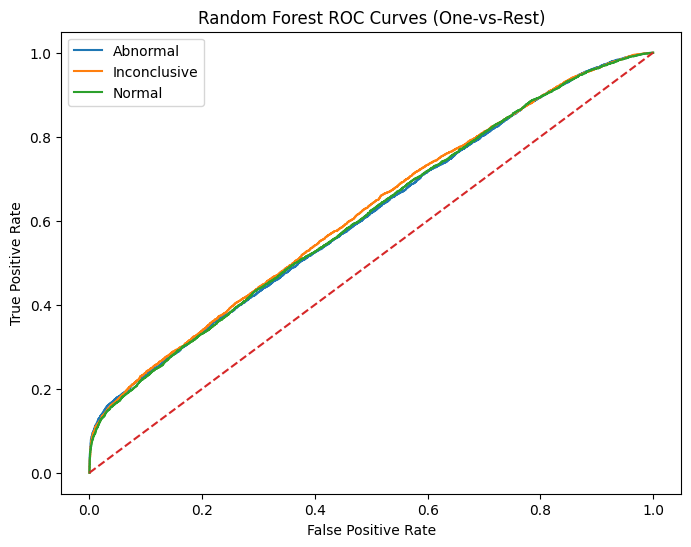

In [22]:
y_test_bin = label_binarize(y_test, classes=best_rf.classes_)

plt.figure(figsize=(8,6))

for i, class_name in enumerate(best_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_tuned_proba[:, i])
    plt.plot(fpr, tpr, label=f"{class_name}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Since this is a multiclass problem, ROC-AUC was calculated using a one-vs-rest approach. This evaluates how well the model separates each class from the others.

# Training Time for Tuned Random Forest

In [23]:
start = time.time()

grid_rf.fit(X_train_proc, y_train)

rf_tuned_time = time.time() - start

# Baseline XGBoost

In [24]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded,
    test_size=0.3,
    stratify=y_encoded,
    random_state=42
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Class mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)

Class mapping:
0 -> Abnormal
1 -> Inconclusive
2 -> Normal


XGBoost works better with numeric target labels so here we are turning the classes into numerical encodings 

In [25]:
xgb_baseline = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42,
)

xgb_baseline.fit(X_train_proc, y_train_enc)

xgb_base_pred = xgb_baseline.predict(X_test_proc)
xgb_base_proba = xgb_baseline.predict_proba(X_test_proc)

xgb_base_accuracy = accuracy_score(y_test_enc, xgb_base_pred)
xgb_base_f1 = f1_score(y_test_enc, xgb_base_pred, average="macro")
xgb_base_auc = roc_auc_score(y_test_enc, xgb_base_proba, multi_class="ovr")

print("Baseline XGBoost Accuracy:", xgb_base_accuracy)
print("Baseline XGBoost F1-Macro:", xgb_base_f1)
print("Baseline XGBoost ROC-AUC:", xgb_base_auc)

Baseline XGBoost Accuracy: 0.3700900900900901
Baseline XGBoost F1-Macro: 0.369944600160705
Baseline XGBoost ROC-AUC: 0.5430674876567014


The XGBoost was trained using multiclass log loss as the evaluation metric. This model serves as the gradient boosting comparison to Random Forest.

In [26]:
#early stopping 
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_proc,
    y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)

# Training Time for Baseline XGBoost

In [27]:
start = time.time()

xgb_baseline.fit(X_train_proc, y_train_enc)

xgb_base_time = time.time() - start

Validation split for early stopping --> splitting the data into training and validation set --> This lets XGBoost stop training when validation performance stops improving

# Tuning XGBoost with GridSearchCV

In [28]:
xgb_model = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)

param_grid = {
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train_part, y_train_part)

best_params = grid_xgb.best_params_
print("Best XGBoost params:", best_params)

c:\Users\amber\anaconda3\envs\iaf604\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [29]:
#refit the XGBoost model with best params and early stopping --> helps prevent overfitting and find optimal number of trees
final_xgb = XGBClassifier(
    **best_params,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=10
)

final_xgb.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

c:\Users\amber\anaconda3\envs\iaf604\Lib\site-packages\xgboost\callback.py:385: UserWarning: [15:03:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [30]:
#evaluate tuned XGBoost
xgb_tuned_pred = final_xgb.predict(X_test_proc)
xgb_tuned_proba = final_xgb.predict_proba(X_test_proc)

xgb_tuned_accuracy = accuracy_score(y_test_enc, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test_enc, xgb_tuned_pred, average="macro")
xgb_tuned_recall = recall_score(y_test_enc, xgb_tuned_pred, average="macro")
xgb_tuned_f1 = f1_score(y_test_enc, xgb_tuned_pred, average="macro")
xgb_tuned_auc = roc_auc_score(y_test_enc, xgb_tuned_proba, multi_class="ovr")

print("Tuned XGBoost Accuracy:", xgb_tuned_accuracy)
print("Tuned XGBoost Precision:", xgb_tuned_precision)
print("Tuned XGBoost Recall:", xgb_tuned_recall)
print("Tuned XGBoost F1-Macro:", xgb_tuned_f1)
print("Tuned XGBoost ROC-AUC:", xgb_tuned_auc)

Tuned XGBoost Accuracy: 0.34684684684684686
Tuned XGBoost Precision: 0.34724609106464915
Tuned XGBoost Recall: 0.34642741900089186
Tuned XGBoost F1-Macro: 0.3428475360127621
Tuned XGBoost ROC-AUC: 0.512614899447557


The tuned XGBoost model was evaluated on the held-out test set using multiple metrics. Comparing these values to the Random Forest results shows whether boosting captured patterns more effectively.

# XGBoost classification report and confusion matrix


              precision    recall  f1-score   support

    Abnormal       0.35      0.45      0.39      5588
Inconclusive       0.35      0.27      0.30      5507
      Normal       0.34      0.33      0.33      5555

    accuracy                           0.35     16650
   macro avg       0.35      0.35      0.34     16650
weighted avg       0.35      0.35      0.34     16650



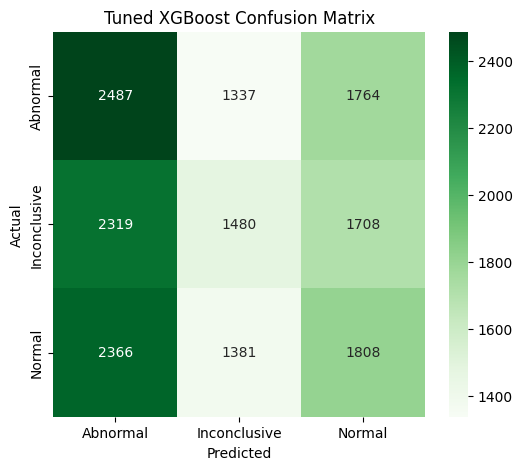

In [31]:
print(classification_report(y_test_enc, xgb_tuned_pred, target_names=label_encoder.classes_))

xgb_cm = confusion_matrix(y_test_enc, xgb_tuned_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# XGBoost Feature Importance

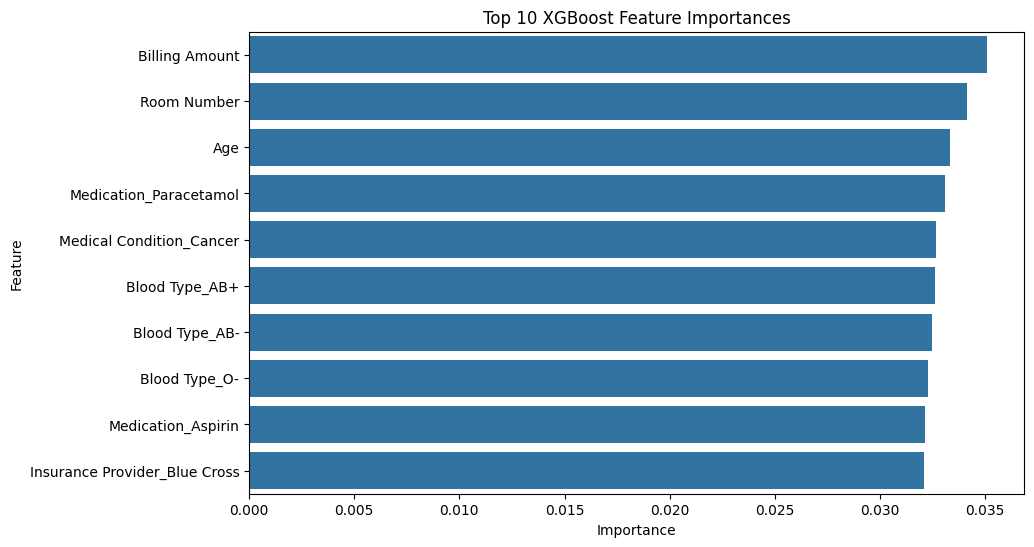

,Feature,Importance
1,Billing Amount,0.035092
2,Room Number,0.034151
0,Age,0.033337
26,Medication_Paracetamol,0.033093
16,Medical Condition_Cancer,0.032656
8,Blood Type_AB+,0.032620
9,Blood Type_AB-,0.032459
13,Blood Type_O-,0.032303
23,Medication_Aspirin,0.032136
29,Insurance Provider_Blue Cross,0.032078


In [32]:
xgb_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": final_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_top10 = xgb_importances.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=xgb_top10, x="Importance", y="Feature")
plt.title("Top 10 XGBoost Feature Importances")
plt.show()

xgb_top10

XGBoost feature importance helps identify which variables were most useful for splits across the boosted trees. This supports interpretability even when predictive performance is only moderate.

# ROC Curve for XGBoost

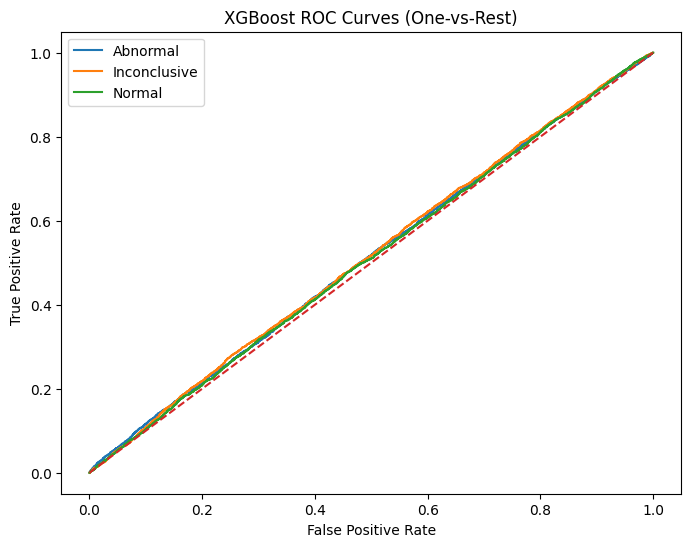

In [33]:
y_test_bin_xgb = label_binarize(y_test_enc, classes=np.unique(y_test_enc))

plt.figure(figsize=(8,6))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin_xgb[:, i], xgb_tuned_proba[:, i])
    plt.plot(fpr, tpr, label=f"{class_name}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("XGBoost ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Training Time for Tuned XGBoost

In [34]:
start = time.time()

final_xgb.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_tuned_time = time.time() - start

c:\Users\amber\anaconda3\envs\iaf604\Lib\site-packages\xgboost\callback.py:385: UserWarning: [15:04:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


# COMPARISON

In [35]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF", "Baseline XGBoost", "Tuned XGBoost"],
    "Accuracy": [rf_base_accuracy, rf_tuned_accuracy, xgb_base_accuracy, xgb_tuned_accuracy],
    "F1-Macro": [rf_base_f1, rf_tuned_f1, xgb_base_f1, xgb_tuned_f1],
    "ROC-AUC": [rf_base_auc, rf_tuned_auc, xgb_base_auc, xgb_tuned_auc],
    "Training Time (sec)": [rf_base_time, rf_tuned_time, xgb_base_time, xgb_tuned_time]
}).round(3)

comparison_df

,Model,Accuracy,F1-Macro,ROC-AUC,Training Time (sec)
0,Baseline RF,0.423,0.423,0.624,0.912
1,Tuned RF,0.423,0.423,0.611,28.371
2,Baseline XGBoost,0.370,0.370,0.543,0.442
3,Tuned XGBoost,0.347,0.343,0.513,0.240


After comparing all four models, the baseline Random Forest performed the best overall. It achieved the highest accuracy, F1-macro score, and ROC-AUC, indicating it was the most consistent at predicting across all three classes. The tuned Random Forest showed almost no improvement and slightly decreased in ROC-AUC, suggesting that the default parameters were already close to optimal for this dataset.

XGBoost performed worse than Random Forest in both its baseline and tuned versions. In fact, tuning XGBoost led to a further decrease in performance, which suggests that increasing model complexity did not help capture meaningful patterns in the data. This may be due to the synthetic nature of the dataset or limited predictive relationships between the features and the target variable.

The lack of improvement from hyperparameter tuning indicates that the limiting factor in model performance is likely the quality and signal strength of the features rather than the model choice itself. This highlights an important concept in we have been learning in class: better models do not always lead to better results if the underlying data does not contain strong predictive information.

Interestingly, the tuned XGBoost model trained faster than the baseline version. This is likely due to early stopping, which stops training once performance on the validation set stops improving. As a result, the model may not use all estimators, reducing training time.

In contrast, Random Forest tuning significantly increased training time because GridSearchCV evaluates multiple parameter combinations using cross-validation.

Predicting test results in a healthcare setting could help providers identify patients who may require additional attention or follow-up care. For example, patients predicted to have abnormal results could be prioritized for faster diagnosis or treatment. Additionally, understanding patterns related to billing, length of stay, and admission type could help hospitals improve resource allocation and operational planning. Although this dataset is synthetic, the project demonstrates how classification models can support decision-making in healthcare environments.

Overall, Random Forest was the most reliable model for this classification task, and its simplicity and stability made it preferable over XGBoost in this case.